In [20]:
import pandas as pd
import numpy as np
import requests
import gc
from tqdm.notebook import tqdm
import time
import re
import os
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization & Stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# RL & Optimization
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN, PPO
from ortools.linear_solver import pywraplp

from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3 import A2C
from torch.distributions import Categorical
import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy

# Create directories
os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

In [4]:
EUROSTAT_FILE = "apro_cpshr$defaultview_spreadsheet.xlsx"
FAOSTAT_FILE = "FAOSTAT_data_en_7-27-2026.csv"

OUTPUT_DIR = Path("processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)



fao = pd.read_csv(
    FAOSTAT_FILE,
    low_memory=False
)

print("\n================ FAOSTAT ================")
print("Shape:", fao.shape)
print("\nColumns:")
print(fao.columns.tolist())

print("\nFirst five rows:")
print(fao.head())


# Keep France only.
# The uploaded dataset already contains France, but this makes
# the code safe if the file is later replaced by a larger file.

fao_france = fao[
    fao["Area"].astype(str).str.strip().str.lower() == "france"
].copy()


# Keep agricultural crop-production variables relevant to
# the project.

useful_elements = [
    "Area harvested",
    "Yield",
    "Production"
]

fao_france = fao_france[
    fao_france["Element"].isin(useful_elements)
].copy()


# Ensure year/value are numeric

fao_france["Year"] = pd.to_numeric(
    fao_france["Year"],
    errors="coerce"
)

fao_france["Value"] = pd.to_numeric(
    fao_france["Value"],
    errors="coerce"
)


print("\nFAOSTAT France shape:", fao_france.shape)
print(
    "Years:",
    int(fao_france["Year"].min()),
    "-",
    int(fao_france["Year"].max())
)

print(
    "Number of agricultural items:",
    fao_france["Item"].nunique()
)



# Create separate columns for:
# - area harvested
# - yield
# - production

fao_wide = fao_france.pivot_table(
    index=[
        "Area",
        "Item Code (CPC)",
        "Item",
        "Year"
    ],
    columns="Element",
    values="Value",
    aggfunc="first"
).reset_index()

fao_wide.columns.name = None


# Rename variables

fao_wide = fao_wide.rename(
    columns={
        "Area": "country",
        "Item Code (CPC)": "crop_code",
        "Item": "crop",
        "Area harvested": "fao_area_harvested_ha",
        "Yield": "fao_yield_kg_ha",
        "Production": "fao_production_tonnes"
    }
)


print("\nFAOSTAT transformed:")
print(fao_wide.head())




excel = pd.ExcelFile(EUROSTAT_FILE)

print("\n================ EUROSTAT ================")
print("Available sheets:")
print(excel.sheet_names)



def parse_eurostat_sheet(file_path, sheet_name):
    """
    Parse one Eurostat spreadsheet sheet.

    The downloaded Eurostat workbook contains metadata before
    the actual table, so the parser identifies:

        Crop category
        Production structure
        Years
        Geographic regions

    It returns a tidy region-year table.
    """

    raw = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        header=None
    )

    # Skip non-data sheets
    if raw.shape[0] < 10 or raw.shape[1] < 3:
        return pd.DataFrame()

    # --------------------------------------------------------
    # Extract metadata
    # --------------------------------------------------------

    crop_category = raw.iloc[5, 2]
    production_structure = raw.iloc[6, 2]

    if pd.isna(crop_category):
        return pd.DataFrame()

    # --------------------------------------------------------
    # Find row containing TIME
    # --------------------------------------------------------

    time_row = None

    for i in range(len(raw)):
        if str(raw.iloc[i, 0]).strip() == "TIME":
            time_row = i
            break

    if time_row is None:
        return pd.DataFrame()

    # --------------------------------------------------------
    # Extract year columns
    # --------------------------------------------------------

    year_columns = {}

    for col in range(1, raw.shape[1]):

        value = raw.iloc[time_row, col]

        try:
            year = int(float(value))

            if 1900 <= year <= 2100:
                year_columns[col] = year

        except (ValueError, TypeError):
            pass

    # --------------------------------------------------------
    # Data begins two rows below TIME
    # --------------------------------------------------------

    data_start = time_row + 2

    records = []

    for row in range(data_start, len(raw)):

        region = raw.iloc[row, 0]

        if pd.isna(region):
            continue

        region = str(region).strip()

        # Skip blank/footer rows
        if region == "":
            continue

        for col, year in year_columns.items():

            value = raw.iloc[row, col]

            # Eurostat missing value marker
            if isinstance(value, str):

                value_clean = value.strip()

                if value_clean in [":", "", "nan"]:
                    value = np.nan

                else:
                    # Remove annotations if embedded
                    match = re.search(
                        r"-?\d+(?:\.\d+)?",
                        value_clean
                    )

                    if match:
                        value = float(match.group())
                    else:
                        value = np.nan

            else:
                value = pd.to_numeric(
                    value,
                    errors="coerce"
                )

            records.append(
                {
                    "region": region,
                    "year": year,
                    "eurostat_crop_category": crop_category,
                    "production_structure": production_structure,
                    "eurostat_value": value
                }
            )

    return pd.DataFrame(records)



eurostat_frames = []

for sheet in excel.sheet_names:

    if sheet.lower() == "summary":
        continue

    print("Reading:", sheet)

    temp = parse_eurostat_sheet(
        EUROSTAT_FILE,
        sheet
    )

    if not temp.empty:
        eurostat_frames.append(temp)


eurostat = pd.concat(
    eurostat_frames,
    ignore_index=True
)


print("\nEurostat parsed shape:", eurostat.shape)

print("\nCrop categories:")
print(
    eurostat["eurostat_crop_category"]
    .drop_duplicates()
    .tolist()
)



# The downloaded Eurostat workbook contains many European
# regions. We select French observations.
#
# Since the spreadsheet labels do not contain country codes,
# we identify the France block in each sheet: it starts with
# "France" and continues until the next country-level entry.
#
# For greater reliability, define known French NUTS regions.

FRENCH_REGIONS = [
    "France",

    "Ile de France",
    "Île-de-France",

    "Centre — Val de Loire",
    "Centre-Val de Loire",

    "Bourgogne-Franche-Comté",
    "Bourgogne - Franche-Comté",

    "Normandie",

    "Hauts-de-France",

    "Grand Est",

    "Pays de la Loire",

    "Bretagne",

    "Nouvelle-Aquitaine",

    "Occitanie",

    "Auvergne-Rhône-Alpes",

    "Provence-Alpes-Côte d’Azur",
    "Provence-Alpes-Côte d'Azur",

    "Corse",

    "Guadeloupe",

    "Martinique",

    "Guyane",

    "La Réunion",
    "Mayotte"
]


def normalise_text(value):

    value = str(value).strip().lower()

    replacements = {
        "î": "i",
        "é": "e",
        "è": "e",
        "ê": "e",
        "à": "a",
        "â": "a",
        "ô": "o",
        "ù": "u",
        "ç": "c",
        "’": "'",
        "—": "-"
    }

    for old, new in replacements.items():
        value = value.replace(old, new)

    value = re.sub(r"\s+", " ", value)

    return value


french_region_normalised = {
    normalise_text(x)
    for x in FRENCH_REGIONS
}


eurostat["region_normalised"] = (
    eurostat["region"]
    .apply(normalise_text)
)


eurostat_france = eurostat[
    eurostat["region_normalised"]
    .isin(french_region_normalised)
].copy()


# Remove exact duplicates that may occur because Eurostat
# sometimes presents overlapping geographic classifications.

eurostat_france = eurostat_france.drop_duplicates(
    subset=[
        "region_normalised",
        "year",
        "eurostat_crop_category",
        "production_structure",
        "eurostat_value"
    ]
)


print("\nFrench Eurostat shape:")
print(eurostat_france.shape)

print("\nFrench regions detected:")
print(
    sorted(
        eurostat_france["region"]
        .drop_duplicates()
        .tolist()
    )
)




# The uploaded workbook is currently an AREA measure in
# thousand hectares.

eurostat_france = eurostat_france.rename(
    columns={
        "eurostat_value":
            "eurostat_area_thousand_ha"
    }
)


# Convert thousand hectares to hectares

eurostat_france[
    "eurostat_area_ha"
] = (
    eurostat_france[
        "eurostat_area_thousand_ha"
    ] * 1000
)



# Representative coordinates for metropolitan French regions.
# These are used only to query regional historical weather.
#
# Overseas regions can be added later if required.

REGION_COORDINATES = {
    "Ile de France": (48.8566, 2.3522),
    "Île-de-France": (48.8566, 2.3522),

    "Centre — Val de Loire": (47.9029, 1.9093),
    "Centre-Val de Loire": (47.9029, 1.9093),

    "Bourgogne-Franche-Comté": (47.3220, 5.0415),
    "Bourgogne - Franche-Comté": (47.3220, 5.0415),

    "Normandie": (49.1829, -0.3707),

    "Hauts-de-France": (50.6292, 3.0573),

    "Grand Est": (48.5734, 7.7521),

    "Pays de la Loire": (47.2184, -1.5536),

    "Bretagne": (48.1173, -1.6778),

    "Nouvelle-Aquitaine": (44.8378, -0.5792),

    "Occitanie": (43.6047, 1.4442),

    "Auvergne-Rhône-Alpes": (45.7640, 4.8357),

    "Provence-Alpes-Côte d’Azur": (43.2965, 5.3698),
    "Provence-Alpes-Côte d'Azur": (43.2965, 5.3698),

    "Corse": (41.9192, 8.7386)
}



def download_weather(
    region,
    latitude,
    longitude,
    start_date="2015-01-01",
    end_date="2024-12-31"
):
    """
    Download daily historical weather from Open-Meteo.

    Variables:
        Mean temperature
        Minimum temperature
        Maximum temperature
        Precipitation
        Rain
        ET0

    These variables will later support calculation of:
        cold-event probabilities
        low-rain probabilities
        weather variability
        crop-weather sensitivity
    """

    url = (
        "https://archive-api.open-meteo.com/"
        "v1/archive"
    )

    params = {
        "latitude": latitude,
        "longitude": longitude,

        "start_date": start_date,
        "end_date": end_date,

        "daily": ",".join([
            "temperature_2m_mean",
            "temperature_2m_min",
            "temperature_2m_max",
            "precipitation_sum",
            "rain_sum",
            "et0_fao_evapotranspiration"
        ]),

        "timezone": "Europe/Paris",

        # Consistent historical reanalysis model
        "models": "era5"
    }

    response = requests.get(
        url,
        params=params,
        timeout=120
    )

    response.raise_for_status()

    data = response.json()

    if "daily" not in data:
        raise ValueError(
            f"No daily weather returned for {region}"
        )

    daily = pd.DataFrame(
        data["daily"]
    )

    daily["region"] = region
    daily["latitude_requested"] = latitude
    daily["longitude_requested"] = longitude

    daily["latitude_returned"] = data.get(
        "latitude"
    )

    daily["longitude_returned"] = data.get(
        "longitude"
    )

    daily["elevation_m"] = data.get(
        "elevation"
    )

    return daily




weather_frames = []

for region, coordinates in REGION_COORDINATES.items():

    # Avoid duplicate alternative names
    if region not in eurostat_france["region"].values:
        continue

    latitude, longitude = coordinates

    print(
        f"Downloading weather: {region}"
    )

    try:

        weather_region = download_weather(
            region,
            latitude,
            longitude,
            start_date="2015-01-01",
            end_date="2024-12-31"
        )

        weather_frames.append(
            weather_region
        )

        # Be polite to API
        time.sleep(0.5)

    except Exception as error:

        print(
            f"ERROR for {region}: {error}"
        )


weather_daily = pd.concat(
    weather_frames,
    ignore_index=True
)



weather_daily["date"] = pd.to_datetime(
    weather_daily["time"]
)

weather_daily["year"] = (
    weather_daily["date"].dt.year
)

weather_daily["month"] = (
    weather_daily["date"].dt.month
)

weather_daily["region_normalised"] = (
    weather_daily["region"]
    .apply(normalise_text)
)


print("\nWeather data shape:")
print(weather_daily.shape)

print(weather_daily.head())



# We preserve daily data separately.
#
# For integration with annual agricultural data, calculate
# annual regional weather summaries.

weather_annual = (
    weather_daily
    .groupby(
        [
            "region",
            "region_normalised",
            "year"
        ],
        as_index=False
    )
    .agg(
        annual_mean_temperature_c=(
            "temperature_2m_mean",
            "mean"
        ),

        annual_min_temperature_c=(
            "temperature_2m_min",
            "min"
        ),

        annual_max_temperature_c=(
            "temperature_2m_max",
            "max"
        ),

        annual_precipitation_mm=(
            "precipitation_sum",
            "sum"
        ),

        annual_rain_mm=(
            "rain_sum",
            "sum"
        ),

        annual_et0_mm=(
            "et0_fao_evapotranspiration",
            "sum"
        )
    )
)




regional_agriculture_weather = pd.merge(
    eurostat_france,
    weather_annual.drop(
        columns=["region"]
    ),
    on=[
        "region_normalised",
        "year"
    ],
    how="left"
)


print(
    "\nRegional agriculture + weather:",
    regional_agriculture_weather.shape
)




fao_year_summary = (
    fao_wide
    .groupby(
        "Year",
        as_index=False
    )
    .agg(
        fao_total_harvested_area_ha=(
            "fao_area_harvested_ha",
            "sum"
        ),

        fao_total_production_tonnes=(
            "fao_production_tonnes",
            "sum"
        ),

        fao_number_of_items=(
            "crop",
            "nunique"
        )
    )
    .rename(
        columns={
            "Year": "year"
        }
    )
)




combined_data = pd.merge(
    regional_agriculture_weather,
    fao_year_summary,
    on="year",
    how="left"
)


# Add source-identification columns

combined_data["country"] = "France"

combined_data["eurostat_source"] = (
    "Eurostat APRO_CPSHR"
)

combined_data["weather_source"] = (
    "Open-Meteo ERA5 Historical Weather"
)

combined_data["national_crop_source"] = (
    "FAOSTAT QCL"
)




combined_data = combined_data.sort_values(
    [
        "region",
        "eurostat_crop_category",
        "year"
    ]
).reset_index(drop=True)




# Keeping intermediate datasets is VERY important for
# reproducibility.

fao_france.to_csv(
    OUTPUT_DIR / "faostat_france_raw_selected.csv",
    index=False
)

fao_wide.to_csv(
    OUTPUT_DIR / "faostat_france_crop_year.csv",
    index=False
)

eurostat_france.to_csv(
    OUTPUT_DIR / "eurostat_france_regions.csv",
    index=False
)

weather_daily.to_csv(
    OUTPUT_DIR / "france_weather_daily.csv",
    index=False
)

weather_annual.to_csv(
    OUTPUT_DIR / "france_weather_annual.csv",
    index=False
)

regional_agriculture_weather.to_csv(
    OUTPUT_DIR /
    "regional_agriculture_weather.csv",
    index=False
)

combined_data.to_csv(
    OUTPUT_DIR /
    "france_agriculture_combined_raw.csv",
    index=False
)



excel_output = (
    OUTPUT_DIR /
    "france_agriculture_integrated_data.xlsx"
)

with pd.ExcelWriter(
    excel_output,
    engine="openpyxl"
) as writer:

    combined_data.to_excel(
        writer,
        sheet_name="Combined",
        index=False
    )

    eurostat_france.to_excel(
        writer,
        sheet_name="Eurostat",
        index=False
    )

    fao_wide.to_excel(
        writer,
        sheet_name="FAOSTAT",
        index=False
    )

    weather_annual.to_excel(
        writer,
        sheet_name="Weather_Annual",
        index=False
    )

    # Daily weather can be large but remains within
    # Excel's row limit for these regions/years.
    weather_daily.to_excel(
        writer,
        sheet_name="Weather_Daily",
        index=False
    )



print("\n================ VALIDATION ================")

print(
    "\nCombined shape:",
    combined_data.shape
)

print(
    "\nYears:",
    combined_data["year"].min(),
    "-",
    combined_data["year"].max()
)

print(
    "\nRegions:",
    combined_data["region"].nunique()
)

print(
    "\nEurostat crop categories:",
    combined_data[
        "eurostat_crop_category"
    ].nunique()
)

print(
    "\nMissing weather observations:"
)

print(
    combined_data[
        [
            "annual_mean_temperature_c",
            "annual_precipitation_mm"
        ]
    ].isna().sum()
)

print(
    "\nMissing FAOSTAT observations:"
)

print(
    combined_data[
        [
            "fao_total_harvested_area_ha",
            "fao_total_production_tonnes"
        ]
    ].isna().sum()
)


# Check duplicates

duplicate_count = combined_data.duplicated(
    subset=[
        "region_normalised",
        "year",
        "eurostat_crop_category"
    ]
).sum()

print(
    "\nPotential region/year/crop duplicates:",
    duplicate_count
)



print("\n================ FINAL DATA ================")

print(
    combined_data.head(20).to_string()
)


print("\nFiles created in:")
print(OUTPUT_DIR.resolve())

print("\nMain dataset:")
print(
    OUTPUT_DIR /
    "france_agriculture_combined_raw.csv"
)

print("\nIntegration completed successfully.")


================ FAOSTAT ================
Shape: (1440, 15)

Columns:
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']

First five rows:
  Domain Code                        Domain  Area Code (M49)    Area  \
0         QCL  Crops and livestock products              250  France   
1         QCL  Crops and livestock products              250  France   
2         QCL  Crops and livestock products              250  France   
3         QCL  Crops and livestock products              250  France   
4         QCL  Crops and livestock products              250  France   

   Element Code         Element Item Code (CPC)               Item  Year Code  \
0          5312  Area harvested           01371  Almonds, in shell       2020   
1          5412           Yield           01371  Almonds, in shell       2020   
2          5510      Production           01371  Almon

In [5]:
def load_and_process_config(data_path="processed_data/france_agriculture_combined_raw.csv"):
    """
    Processes raw combined data into simulation configuration.

    UPDATES:
    - Fix D: Maps FAOSTAT items to simulation categories for realistic yields.
    - Fix E: Calculates empirical weather probabilities from historical data.
    - Fix F/G: Adds explicit economic parameters and sensitivity assumptions.
    """
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Data file not found at {data_path}. Please ensure previous data ingestion steps were completed.")

    df = pd.read_csv(data_path)

    # Filter relevant crops
    relevant_categories = [
        'Cereals for the production of grain (including seed)',
        'Dry pulses and protein crops for the production of grain (including seed and mixtures of cereals and pulses)',
        'Permanent grassland'
    ]
    sim_df = df[df['eurostat_crop_category'].isin(relevant_categories)].copy()

    # --- Phase 2: Regional Structure & Stats ---
    # Calculate baselines per Region and Crop
    region_crop_stats = sim_df.groupby(['region_normalised', 'eurostat_crop_category']).agg(
        avg_area_ha=('eurostat_area_ha', 'mean'),
        count_years=('year', 'count')
    ).reset_index()

    # --- FIX D: Realistic Yield Mapping ---
    # Instead of using a single national average for all crops, we map specific
    # FAOSTAT items to our simulation categories to get category-specific yields.

    # Define keywords for mapping
    cereal_keywords = ['wheat', 'barley', 'maize', 'corn', 'oats', 'rye', 'sorghum', 'rice', 'triticale']
    pulse_keywords = ['beans', 'peas', 'lentils', 'chickpeas', 'lupins', 'vetches']
    grassland_keywords = ['grass', 'forage', 'pasture', 'hay', 'silage', 'permanent']

    def map_crop(item_name):
        item_lower = str(item_name).lower()
        if any(k in item_lower for k in cereal_keywords):
            return 'Cereals for the production of grain (including seed)'
        elif any(k in item_lower for k in pulse_keywords):
            return 'Dry pulses and protein crops for the production of grain (including seed and mixtures of cereals and pulses)'
        elif any(k in item_lower for k in grassland_keywords):
            return 'Permanent grassland'
        return None


    national_yearly = sim_df.dropna(subset=['fao_total_production_tonnes', 'fao_total_harvested_area_ha']).copy()

    # Calculate yield per year for the whole country for each category
    national_yearly['yield_kg_ha'] = (national_yearly['fao_total_production_tonnes'] * 1000) / national_yearly['fao_total_harvested_area_ha']

    # Average the yearly yields to get a stable baseline
    national_crop_yield = national_yearly.groupby('eurostat_crop_category')['yield_kg_ha'].mean().reset_index()
    national_crop_yield.columns = ['eurostat_crop_category', 'national_avg_yield']

    # Merge national yield back to regional stats
    region_crop_stats = region_crop_stats.merge(national_crop_yield, on='eurostat_crop_category', how='left')
    region_crop_stats['base_yield_kg_ha'] = region_crop_stats['national_avg_yield']

    # Fill NaNs with global average if specific crop data is missing
    global_avg_yield = region_crop_stats['base_yield_kg_ha'].mean()
    region_crop_stats['base_yield_kg_ha'] = region_crop_stats['base_yield_kg_ha'].fillna(global_avg_yield)

    # --- Phase 3: Weather Event Modelling ---
    # Handle missing weather data: Keep only rows with weather data for threshold calculation
    weather_df = sim_df[['region_normalised', 'year', 'annual_mean_temperature_c', 'annual_precipitation_mm']].dropna()

    # Calculate thresholds per region
    weather_stats = weather_df.groupby('region_normalised').agg(
        mean_temp=('annual_mean_temperature_c', 'mean'),
        std_temp=('annual_mean_temperature_c', 'std'),
        mean_precip=('annual_precipitation_mm', 'mean'),
        std_precip=('annual_precipitation_mm', 'std'),
        count_years=('year', 'count')
    ).reset_index()

    # Define Thresholds: Cold = Mean - 1 StdDev, Low Rain = Mean - 1 StdDev
    weather_stats['cold_threshold'] = weather_stats['mean_temp'] - weather_stats['std_temp']
    weather_stats['low_rain_threshold'] = weather_stats['mean_precip'] - weather_stats['std_precip']

    # --- FIX E: Empirical Weather Probabilities ---
    # Calculate actual frequency of adverse events from historical data
    def calc_empirical_probs(row):
        region_data = weather_df[weather_df['region_normalised'] == row['region_normalised']]
        if region_data.empty or row['count_years'] == 0:
            return 0.16, 0.16 # Fallback

        n_cold = (region_data['annual_mean_temperature_c'] < row['cold_threshold']).sum()
        n_dry = (region_data['annual_precipitation_mm'] < row['low_rain_threshold']).sum()

        p_cold = n_cold / row['count_years']
        p_rain = n_dry / row['count_years']

        # Clamp to reasonable bounds to avoid 0 or 1 extremes in simulation
        return max(0.05, min(0.5, p_cold)), max(0.05, min(0.5, p_rain))

    probs = weather_stats.apply(calc_empirical_probs, axis=1, result_type='expand')
    weather_stats['p_cold'], weather_stats['p_low_rain'] = probs[0], probs[1]

    # --- FIX F: Crop Sensitivities (Labelled Assumptions) ---
    crop_sensitivity = {
        'Cereals for the production of grain (including seed)': {'cold': 0.10, 'rain': 0.15},
        'Dry pulses and protein crops for the production of grain (including seed and mixtures of cereals and pulses)': {'cold': 0.05, 'rain': 0.20},
        'Permanent grassland': {'cold': 0.02, 'rain': 0.25}
    }

    region_crop_stats['cold_sens'] = region_crop_stats['eurostat_crop_category'].map(lambda x: crop_sensitivity.get(x, {'cold':0.1, 'rain':0.1})['cold'])
    region_crop_stats['rain_sens'] = region_crop_stats['eurostat_crop_category'].map(lambda x: crop_sensitivity.get(x, {'cold':0.1, 'rain':0.1})['rain'])

    # --- FIX G: Economic Parameters ---
    # Distinct local and international prices (EUR/tonne)
    economic_params = {
        'Cereals for the production of grain (including seed)': {'local_price': 220, 'int_price': 200},
        'Dry pulses and protein crops for the production of grain (including seed and mixtures of cereals and pulses)': {'local_price': 350, 'int_price': 320},
        'Permanent grassland': {'local_price': 150, 'int_price': 140}
    }

    # --- Phase 5: 100-Unit Discretization ---
    regions = region_crop_stats['region_normalised'].unique().tolist()
    crops = region_crop_stats['eurostat_crop_category'].unique().tolist()

    # Calculate total agricultural area per region
    region_total_area = region_crop_stats.groupby('region_normalised')['avg_area_ha'].sum()
    total_france_area = region_total_area.sum()

    # Allocate 100 units proportionally
    n_units_total = 100
    region_units = (region_total_area / total_france_area * n_units_total).round().astype(int)

    # Adjust to ensure sum is exactly 100
    diff = n_units_total - region_units.sum()
    if diff != 0:
        region_units.iloc[0] += diff

    config = {
        'regions': regions,
        'crops': crops,
        'region_crop_stats': region_crop_stats,
        'weather_stats': weather_stats,
        'region_units': region_units.to_dict(),
        'n_units_total': n_units_total,
        'crop_sensitivity': crop_sensitivity,
        'economic_params': economic_params # Added for Fix G
    }

    return config

print("Loading Configuration...")
config = load_and_process_config()
print(f"Config Loaded: {len(config['regions'])} Regions, {len(config['crops'])} Crops")
print(f"Units per Region: {config['region_units']}")
print("\nSample Weather Probabilities (Empirical):")
print(config['weather_stats'][['region_normalised', 'p_cold', 'p_low_rain']].head())
print("\nEconomic Parameters:")
print(config['economic_params'])

Loading Configuration...
Config Loaded: 19 Regions, 3 Crops
Units per Region: {'auvergne-rhone-alpes': 3, 'bourgogne-franche-comte': 4, 'bretagne': 3, 'centre - val de loire': 7, 'corse': 0, 'france': 50, 'grand est': 7, 'guadeloupe': 0, 'guyane': 0, 'hauts-de-france': 6, 'ile de france': 2, 'la reunion': 0, 'martinique': 0, 'mayotte': 0, 'normandie': 3, 'nouvelle-aquitaine': 7, 'occitanie': 4, 'pays de la loire': 4, "provence-alpes-cote d'azur": 0}

Sample Weather Probabilities (Empirical):
         region_normalised  p_cold  p_low_rain
0  bourgogne-franche-comte     0.2         0.2
1    centre - val de loire     0.2         0.1
2          hauts-de-france     0.2         0.1
3            ile de france     0.2         0.1
4                normandie     0.2         0.2

Economic Parameters:
{'Cereals for the production of grain (including seed)': {'local_price': 220, 'int_price': 200}, 'Dry pulses and protein crops for the production of grain (including seed and mixtures of cereals and 

In [6]:
class FranceAgriEnv(gym.Env):
    def __init__(self, config=None, seed=None):
        super().__init__()

        self.config = config if config else load_and_process_config()
        self.regions = self.config['regions']
        self.crops = self.config['crops']
        self.region_units = self.config['region_units']
        self.stats = self.config['region_crop_stats']
        self.weather_stats = self.config['weather_stats']

        # FIX G: Load Economic Parameters from Config
        self.econ = self.config.get('economic_params', {
            'Cereals for the production of grain (including seed)': {'local_price': 220, 'int_price': 200},
            'Dry pulses and protein crops for the production of grain (including seed and mixtures of cereals and pulses)': {'local_price': 350, 'int_price': 320},
            'Permanent grassland': {'local_price': 150, 'int_price': 140}
        })

        self.n_regions = len(self.regions)
        self.n_crops = len(self.crops)

        self.region_to_idx = {r: i for i, r in enumerate(self.regions)}
        self.crop_to_idx = {c: i for i, c in enumerate(self.crops)}
        self.idx_to_crop = {i: c for c, i in self.crop_to_idx.items()}

        self.action_space = spaces.Discrete(self.n_crops)

        # State size
        obs_size = 1 + 1 + self.n_crops + 1
        self.observation_space = spaces.Box(low=-10, high=10, shape=(obs_size,), dtype=np.float32)

        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.current_region_idx = 0
        self.units_allocated_in_current_region = 0
        self.max_units_in_current_region = self.region_units[self.regions[0]]

        # Generate Demand
        self.demand_vector = np.zeros(self.n_crops)
        for i, crop in enumerate(self.crops):
            # Use national avg prod from config if available, else fallback
            national_prod = self.config.get('national_avg_prod', {}).get(crop, 10000)
            noise = max(0.1, self.rng.normal(1.0, 0.05))
            self.demand_vector[i] = national_prod * 1.05 * noise # 5% growth factor

        # Safety check
        self.demand_vector[self.demand_vector == 0] = 1.0

        self.production_vector = np.zeros(self.n_crops)

        # FIX: Initialize tracking matrices for comprehensive metrics
        self.allocation_matrix = np.zeros((self.n_regions, self.n_crops))
        self.weather_history = []
        self.weather_shock_active = False

        return self._get_obs(), {}

    def _get_obs(self):
        region_norm = self.current_region_idx / max(1, self.n_regions)
        units_norm = self.units_allocated_in_current_region / max(1, self.max_units_in_current_region)

        # Normalized Deficit
        deficit = np.maximum(self.demand_vector - self.production_vector, 0)
        # Safe division
        deficit_norm = deficit / (self.demand_vector + 1e-8)

        # Clip to prevent extreme values
        deficit_norm = np.clip(deficit_norm, 0, 5.0)

        weather_norm = 1.0 if self.weather_shock_active else 0.0

        obs = np.array([region_norm, units_norm, *deficit_norm, weather_norm], dtype=np.float32)

        # CRITICAL: Replace any NaN/Inf with 0
        obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)

        return obs

    def step(self, action):
        # FIX: Ensure action is a standard Python integer
        if isinstance(action, np.ndarray):
            action = int(action.item())
        elif hasattr(action, '__len__') and len(action) == 1:
            action = int(action[0])
        else:
            action = int(action)

        # Safety check for action bounds
        if action < 0 or action >= self.n_crops:
            action = 0

        crop_name = self.idx_to_crop[action]
        region_name = self.regions[self.current_region_idx]

        # Track Allocation
        self.allocation_matrix[self.current_region_idx, action] += 1

        mask = (self.stats['region_normalised'] == region_name) & \
               (self.stats['eurostat_crop_category'] == crop_name)
        subset = self.stats[mask]

        if subset.empty:
            base_yield = 5000
            unit_area = 100
            cold_sens = 0.1
            rain_sens = 0.1
        else:
            base_yield = subset['base_yield_kg_ha'].values[0]
            region_total_area = self.stats[self.stats['region_normalised'] == region_name]['avg_area_ha'].sum()
            if np.isnan(region_total_area) or region_total_area == 0:
                region_total_area = 10000
            unit_area = region_total_area / max(1, self.max_units_in_current_region)
            cold_sens = subset['cold_sens'].values[0]
            rain_sens = subset['rain_sens'].values[0]

        # Weather Simulation
        w_stats = self.weather_stats[self.weather_stats['region_normalised'] == region_name]
        p_cold = w_stats['p_cold'].values[0] if not w_stats.empty else 0.16
        p_rain = w_stats['p_low_rain'].values[0] if not w_stats.empty else 0.16

        is_cold = self.rng.random() < p_cold
        is_dry = self.rng.random() < p_rain

        # Track Weather History for Metrics
        current_weather_state = "Normal"
        if is_cold and is_dry: current_weather_state = "Adverse_Double"
        elif is_cold: current_weather_state = "Adverse_Cold"
        elif is_dry: current_weather_state = "Adverse_Dry"
        self.weather_history.append(current_weather_state)

        loss_cold = cold_sens if is_cold else 0.0
        loss_rain = rain_sens if is_dry else 0.0
        weather_factor = 1.0 - loss_cold - loss_rain
        weather_factor = max(0.1, min(1.0, weather_factor))

        # Production
        produced_kg = unit_area * base_yield * weather_factor
        produced_tonnes = produced_kg / 1000.0

        if np.isnan(produced_tonnes):
            produced_tonnes = 0.0

        self.production_vector[action] += produced_tonnes

        # Reward Calculation
        ratio = self.production_vector[action] / (self.demand_vector[action] + 1e-8)
        demand_met_ratio = min(1.0, max(0.0, ratio))

        reward = float(demand_met_ratio * 5.0)

        if weather_factor < 1.0:
            reward -= 2.0

        self.units_allocated_in_current_region += 1
        done = False
        truncated = False

        if self.units_allocated_in_current_region >= self.max_units_in_current_region:
            self.current_region_idx += 1
            self.units_allocated_in_current_region = 0

            if self.current_region_idx >= self.n_regions:
                done = True
                total_deficit = np.maximum(self.demand_vector - self.production_vector, 0)
                total_surplus = np.maximum(self.production_vector - self.demand_vector, 0)

                # Calculate Final Economic Reward using self.econ
                import_cost = 0.0
                export_revenue = 0.0
                for i, crop in enumerate(self.crops):
                    prices = self.econ.get(crop, {'local_price': 200, 'int_price': 180})
                    import_cost += total_deficit[i] * prices['local_price'] * 1.5
                    export_revenue += total_surplus[i] * prices['int_price']

                net_economic = export_revenue - import_cost
                reward += float(net_economic / 100000.0) # Normalize

            else:
                self.max_units_in_current_region = self.region_units[self.regions[self.current_region_idx]]

        self.weather_shock_active = (is_cold or is_dry)

        if np.isinf(reward) or np.isnan(reward):
            reward = 0.0

        return self._get_obs(), reward, done, truncated, {}

In [7]:
def make_env():
    return FranceAgriEnv(config=config)

In [8]:
# Generate Seeds
print("Generating Training and Test Seeds...")
rng_seeds = np.random.default_rng(42)
train_seeds = rng_seeds.integers(0, 100000, size=100000)
test_seeds = rng_seeds.integers(0, 100000, size=1000)
np.save("logs/train_seeds.npy", train_seeds)
np.save("logs/test_seeds.npy", test_seeds)

Generating Training and Test Seeds...


In [9]:
# --- Train DQN ---
print("\n--- Training DQN Agent ---")
start_time = time.time()
dqn_model = DQN("MlpPolicy", make_env(), verbose=1, learning_rate=1e-3, buffer_size=10000, learning_starts=1000)
dqn_model.learn(total_timesteps=100000)
dqn_train_time = time.time() - start_time
dqn_model.save("models/dqn_final")
print(f"DQN Training Complete in {dqn_train_time:.2f}s")


--- Training DQN Agent ---
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 107      |
|    ep_rew_mean      | 5.65e+05 |
|    exploration_rate | 0.959    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 695      |
|    time_elapsed     | 0        |
|    total_timesteps  | 428      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 107      |
|    ep_rew_mean      | 5.55e+05 |
|    exploration_rate | 0.919    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 696      |
|    time_elapsed     | 1        |
|    total_timesteps  | 856      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 107      |
| 

In [10]:
print("\n--- Training PPO Agent ---")
start_time = time.time()

ppo_model = PPO(
    "MlpPolicy",
    make_env(),
    verbose=1,
    learning_rate=1e-4, # Lower learning rate for stability
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    max_grad_norm=0.5,
    normalize_advantage=True,
    device="cpu"
)

try:
    # Train for just 1 iteration to see if it crashes
    ppo_model.learn(total_timesteps=2048)
    print("First iteration successful!")

    # If successful, continue training
    ppo_model.learn(total_timesteps=100000)

    ppo_train_time = time.time() - start_time
    ppo_model.save("models/ppo_final")
    print(f"PPO Training Complete in {ppo_train_time:.2f}s")

except Exception as e:
    print(f"PPO Training Failed: {e}")
    import traceback
    traceback.print_exc()


--- Training PPO Agent ---
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 107      |
|    ep_rew_mean     | 5.57e+05 |
| time/              |          |
|    fps             | 472      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
First iteration successful!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 107      |
|    ep_rew_mean     | 5.53e+05 |
| time/              |          |
|    fps             | 464      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 107       |
|    ep_rew_mean          | 5.59e+05  |
| time/   

In [11]:
def run_greedy_baseline(env_seed):
    """
    Lightweight Greedy Baseline: Allocates units to the crop with highest expected yield.
    """
    env = FranceAgriEnv(config=config, seed=env_seed)
    env.reset()

    allocation = np.zeros((env.n_regions, env.n_crops))

    # Calculate Expected Profit per Unit for each Crop in each Region
    expected_profits = np.zeros((env.n_regions, env.n_crops))

    for r_idx, region in enumerate(env.regions):
        region_area = env.stats[env.stats['region_normalised'] == region]['avg_area_ha'].sum()
        unit_area = region_area / env.region_units[region]

        for c_idx, crop in enumerate(env.crops):
            mask = (env.stats['region_normalised'] == region) & (env.stats['eurostat_crop_category'] == crop)
            subset = env.stats[mask]
            if not subset.empty:
                base_yield = subset['base_yield_kg_ha'].values[0]
                expected_profits[r_idx, c_idx] = base_yield * unit_area
            else:
                expected_profits[r_idx, c_idx] = 0

    # Greedy Allocation: For each region, fill units with the most profitable crop
    for r_idx in range(env.n_regions):
        units_available = env.region_units[env.regions[r_idx]]

        # Sort crops by profit (descending)
        sorted_crops = np.argsort(expected_profits[r_idx])[::-1]

        for c_idx in sorted_crops:
            if units_available <= 0:
                break
            # Assign all remaining units to the best crop (Simple Greedy)
            # Or distribute proportionally. Here we assign all to top 1 for max efficiency.
            allocation[r_idx, c_idx] = units_available
            units_available = 0

    return allocation

Loading trained models...
Models loaded.
Evaluating on 1000 test instances...

--- Evaluating DQN (1000 Instances) ---


Evaluating DQN:   0%|          | 0/1000 [00:00<?, ?it/s]


--- Evaluating PPO (1000 Instances) ---


Evaluating PPO:   0%|          | 0/1000 [00:00<?, ?it/s]


--- Evaluating Greedy Baseline (1000 Instances) ---


Evaluating Greedy:   0%|          | 0/1000 [00:00<?, ?it/s]


Evaluation Complete. Saved to logs/comprehensive_evaluation_results.csv

================ CHAPTER 4 METRICS SUMMARY ================
               Reward                              Demand_Satisfaction_Pct                 Net_Economic_EUR                             Land_Utilization_Pct                 Crop_Diversity_Index                     Total_Deficit_Tonnes                           Export_Revenue_EUR                             Adverse_Weather_Ratio                    
                 mean           std         median                    mean  std     median             mean           std        median                 mean  std     median                 mean       std    median                 mean         std        median               mean           std        median                  mean       std    median
Model                                                                                                                                                                 

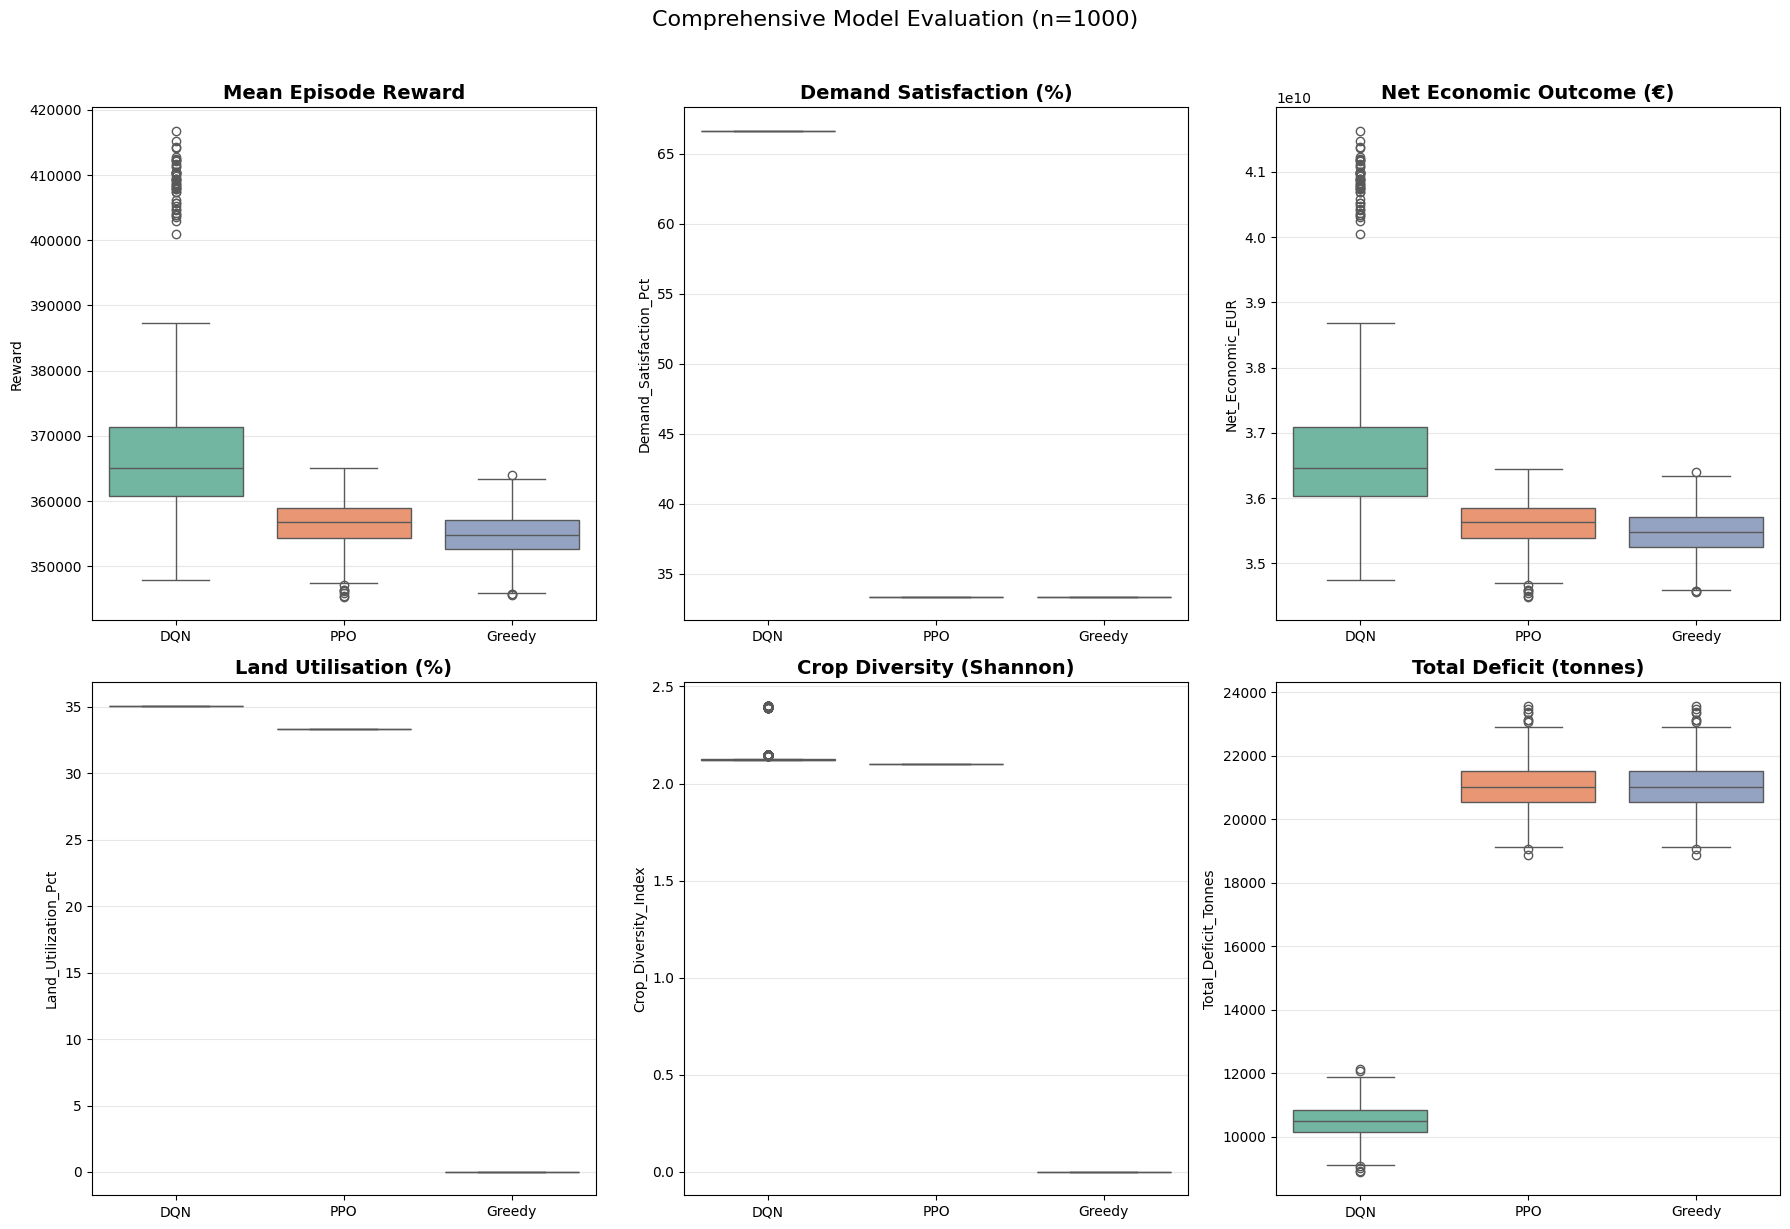

In [12]:
# Load Models
print("Loading trained models...")
dqn_model = DQN.load("models/dqn_final", device="cpu")
ppo_model = PPO.load("models/ppo_final", device="cpu")
print("Models loaded.")

# Load ALL 1000 Test Seeds (Fix A)
test_seeds_loaded = np.load("logs/test_seeds.npy")
print(f"Evaluating on {len(test_seeds_loaded)} test instances...")

def get_weather_probs(env, region_name):
    """Safely retrieve empirical weather probabilities for a region"""
    w_data = env.weather_stats[env.weather_stats['region_normalised'] == region_name]
    if w_data.empty:
        # Fallback defaults if region not found in weather stats
        return 0.16, 0.16
    return w_data['p_cold'].values[0], w_data['p_low_rain'].values[0]

def calculate_comprehensive_metrics(env, ep_reward):
    """
    Calculates all Chapter 4 metrics from a completed environment episode.
    """
    demand = env.demand_vector
    production = env.production_vector

    # Core Vectors
    deficit_vec = np.maximum(demand - production, 0)
    surplus_vec = np.maximum(production - demand, 0)

    # 4.3 Demand Satisfaction
    demand_sat_pct = np.minimum(production / (demand + 1e-8), 1.0).mean() * 100

    # 4.4 Economics (Using config economic params)
    import_cost = 0.0
    export_revenue = 0.0
    for i, crop in enumerate(env.crops):
        prices = env.econ.get(crop, {'local_price': 200, 'int_price': 180})
        import_cost += deficit_vec[i] * prices['local_price'] * 1.5  # Penalty multiplier
        export_revenue += surplus_vec[i] * prices['int_price']

    net_economic = export_revenue - import_cost

    # 4.5 Land Allocation & Utilisation
    alloc_mat = env.allocation_matrix
    total_units = np.sum(alloc_mat)
    land_util_pct = (np.sum(alloc_mat > 0) / alloc_mat.size) * 100 if alloc_mat.size > 0 else 0

    # Crop Diversity (Shannon Entropy)
    diversity = 0.0
    if total_units > 0:
        props = alloc_mat.flatten() / total_units
        props = props[props > 0]
        diversity = -np.sum(props * np.log(props + 1e-8))

    # 4.7 Weather Robustness
    weather_hist = getattr(env, 'weather_history', [])
    n_adverse = sum(1 for w in weather_hist if 'Adverse' in str(w))
    adverse_ratio = n_adverse / len(weather_hist) if weather_hist else 0.0

    return {
        'Reward': ep_reward,
        'Demand_Satisfaction_Pct': demand_sat_pct,
        'Total_Deficit_Tonnes': deficit_vec.sum(),
        'Total_Surplus_Tonnes': surplus_vec.sum(),
        'Export_Revenue_EUR': export_revenue,
        'Import_Cost_EUR': import_cost,
        'Net_Economic_EUR': net_economic,
        'Land_Utilization_Pct': land_util_pct,
        'Crop_Diversity_Index': diversity,
        'Adverse_Weather_Ratio': adverse_ratio
    }

def evaluate_rl_model_comprehensive(model_obj, seeds, model_name):
    records = []
    for seed in tqdm(seeds, desc=f"Evaluating {model_name}"):
        env = FranceAgriEnv(config=config, seed=seed)
        obs, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            action, _ = model_obj.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            ep_reward += reward

        metrics = calculate_comprehensive_metrics(env, ep_reward)
        metrics['Model'] = model_name
        metrics['Seed'] = seed
        records.append(metrics)

    return pd.DataFrame(records)

def evaluate_greedy_comprehensive(seeds):
    records = []
    for seed in tqdm(seeds, desc="Evaluating Greedy"):
        alloc = run_greedy_baseline(seed)
        env = FranceAgriEnv(config=config, seed=seed)
        env.reset()
        total_prod = np.zeros(env.n_crops)

        # Simulate production with weather
        for r_idx, region in enumerate(env.regions):
            p_cold, p_rain = get_weather_probs(env, region)
            region_area = env.stats[env.stats['region_normalised'] == region]['avg_area_ha'].sum()
            unit_area = region_area / max(1, env.region_units[region])

            for c_idx, crop in enumerate(env.crops):
                n_units = int(alloc[r_idx, c_idx])
                if n_units <= 0: continue

                mask = (env.stats['region_normalised'] == region) & \
                       (env.stats['eurostat_crop_category'] == crop)
                subset = env.stats[mask]
                if subset.empty: continue

                base_yield = subset['base_yield_kg_ha'].values[0]
                cold_sens = subset['cold_sens'].values[0]
                rain_sens = subset['rain_sens'].values[0]

                rand_cold = env.rng.random(n_units) < p_cold
                rand_rain = env.rng.random(n_units) < p_rain

                wf = 1.0 - (cold_sens * rand_cold) - (rain_sens * rand_rain)
                wf = np.maximum(0.1, wf)

                total_prod[c_idx] += np.sum(unit_area * base_yield * wf) / 1000.0

        # Manually set production vector so metric calculator works
        env.production_vector = total_prod
        # Greedy doesn't track step-by-step weather history in same way,
        # but we can approximate or leave as 0 for baseline comparison
        env.weather_history = []

        # Calculate reward consistently with RL env terminal reward
        deficit = np.maximum(env.demand_vector - total_prod, 0)
        surplus = np.maximum(total_prod - env.demand_vector, 0)
        greedy_reward = 0.0 # Intermediate rewards are 0 for greedy offline eval
        # Add terminal economic component to make comparable
        for i, crop in enumerate(env.crops):
            prices = env.econ.get(crop, {'local_price': 200, 'int_price': 180})
            greedy_reward += (surplus[i] * prices['int_price']) - (deficit[i] * prices['local_price'] * 1.5)
        greedy_reward /= 100000.0 # Match RL normalization

        metrics = calculate_comprehensive_metrics(env, greedy_reward)
        metrics['Model'] = 'Greedy'
        metrics['Seed'] = seed
        records.append(metrics)

    return pd.DataFrame(records)

# ==============================================================================
# RUN EVALUATIONS
# ==============================================================================

print("\n--- Evaluating DQN (1000 Instances) ---")
df_dqn = evaluate_rl_model_comprehensive(dqn_model, test_seeds_loaded, "DQN")

print("\n--- Evaluating PPO (1000 Instances) ---")
df_ppo = evaluate_rl_model_comprehensive(ppo_model, test_seeds_loaded, "PPO")

print("\n--- Evaluating Greedy Baseline (1000 Instances) ---")
df_greedy = evaluate_greedy_comprehensive(test_seeds_loaded)

# Combine All Results
results_df = pd.concat([df_dqn, df_ppo, df_greedy], ignore_index=True)
results_df.to_csv("logs/comprehensive_evaluation_results.csv", index=False)
print("\nEvaluation Complete. Saved to logs/comprehensive_evaluation_results.csv")

# ==============================================================================
# REPORTING & VISUALIZATION
# ==============================================================================

metric_labels = {
    'Reward': 'Mean Episode Reward',
    'Demand_Satisfaction_Pct': 'Demand Satisfaction (%)',
    'Net_Economic_EUR': 'Net Economic Outcome (€)',
    'Land_Utilization_Pct': 'Land Utilisation (%)',
    'Crop_Diversity_Index': 'Crop Diversity (Shannon)',
    'Total_Deficit_Tonnes': 'Total Deficit (tonnes)',
    'Export_Revenue_EUR': 'Export Revenue (€)',
    'Adverse_Weather_Ratio': 'Adverse Weather Exposure'
}

print("\n================ CHAPTER 4 METRICS SUMMARY ================")
summary_stats = results_df.groupby('Model')[list(metric_labels.keys())].agg(['mean', 'std', 'median'])
print(summary_stats.to_string())

# Statistical Significance Tests (Paired T-Test on Rewards)
print("\n--- Statistical Comparison (Paired T-Test on Reward) ---")
models = results_df['Model'].unique()
for i in range(len(models)):
    for j in range(i+1, len(models)):
        m1, m2 = models[i], models[j]
        r1 = results_df[results_df['Model']==m1]['Reward'].values
        r2 = results_df[results_df['Model']==m2]['Reward'].values
        min_len = min(len(r1), len(r2))
        t_stat, p_val = stats.ttest_rel(r1[:min_len], r2[:min_len])
        sig = "*** SIGNIFICANT ***" if p_val < 0.05 else "n.s."
        print(f"{m1:>8} vs {m2:<8}: T={t_stat:>8.4f}, p={p_val:.6f}  {sig}")

# Comprehensive Dashboard Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
key_metrics = ['Reward', 'Demand_Satisfaction_Pct', 'Net_Economic_EUR',
               'Land_Utilization_Pct', 'Crop_Diversity_Index', 'Total_Deficit_Tonnes']

for ax, metric in zip(axes.flatten(), key_metrics):
    sns.boxplot(x='Model', y=metric, data=results_df, ax=ax, palette="Set2")
    ax.set_title(metric_labels.get(metric, metric), fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comprehensive Model Evaluation (n=1000)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("logs/comprehensive_evaluation_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
summary_stats.T

Model                                    DQN        Greedy           PPO
Reward                  mean    3.677077e+05  3.548317e+05  3.565782e+05
                        std     1.160749e+04  3.276096e+03  3.386121e+03
                        median  3.651188e+05  3.547540e+05  3.568078e+05
Demand_Satisfaction_Pct mean    6.666667e+01  3.333333e+01  3.333333e+01
                        std     0.000000e+00  0.000000e+00  0.000000e+00
                        median  6.666667e+01  3.333333e+01  3.333333e+01
Net_Economic_EUR        mean    3.672365e+10  3.548317e+10  3.561070e+10
                        std     1.160430e+09  3.276096e+08  3.379740e+08
                        median  3.646528e+10  3.547540e+10  3.563334e+10
Land_Utilization_Pct    mean    3.508772e+01  0.000000e+00  3.333333e+01
                        std     0.000000e+00  0.000000e+00  0.000000e+00
                        median  3.508772e+01  0.000000e+00  3.333333e+01
Crop_Diversity_Index    mean    2.138745e+00  0.000000e+00  2.101565e+00
                        std     5.733548e-02  0.000000e+00  0.000000e+00
                        median  2.122587e+00  0.000000e+00  2.101565e+00
Total_Deficit_Tonnes    mean    1.050331e+04  2.103251e+04  2.103251e+04
                        std     5.418763e+02  7.472854e+02  7.472854e+02
                        median  1.051328e+04  2.101029e+04  2.101029e+04
Export_Revenue_EUR      mean    3.672917e+10  3.549216e+10  3.561969e+10
                        std     1.160430e+09  3.276262e+08  3.379760e+08
                        median  3.647089e+10  3.548417e+10  3.564239e+10
Adverse_Weather_Ratio   mean    2.981028e-01  0.000000e+00  2.981028e-01
                        std     4.398936e-02  0.000000e+00  4.398936e-02
                        median  2.990654e-01  0.000000e+00  2.990654e-01

In [14]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# ----------------------------------------------------------
# Function to extract average allocation
# ----------------------------------------------------------

def extract_average_allocation(model=None, model_name="Model", greedy=False):

    allocation_sum = np.zeros((len(config["regions"]), len(config["crops"])))

    for seed in tqdm(test_seeds_loaded, desc=f"{model_name} Allocation"):

        env = FranceAgriEnv(config=config, seed=seed)

        obs, _ = env.reset()

        if greedy:

            alloc = run_greedy_baseline(seed)
            allocation_sum += alloc

        else:

            done = False

            while not done:

                action, _ = model.predict(obs, deterministic=True)

                obs, reward, done, truncated, info = env.step(action)

            allocation_sum += env.allocation_matrix

    mean_alloc = allocation_sum / len(test_seeds_loaded)

    crop_units = mean_alloc.sum(axis=0)

    crop_pct = crop_units / crop_units.sum() * 100

    df = pd.DataFrame({

        "Crop Category": config["crops"],
        "Allocated Units": np.round(crop_units,2),
        "Percentage of Land (%)": np.round(crop_pct,2)

    })

    return df


# ----------------------------------------------------------
# Generate RL allocation tables
# ----------------------------------------------------------

dqn_alloc = extract_average_allocation(
    model=dqn_model,
    model_name="DQN"
)

ppo_alloc = extract_average_allocation(
    model=ppo_model,
    model_name="PPO"
)

greedy_alloc = extract_average_allocation(
    greedy=True,
    model_name="Greedy"
)

print("\n========== DQN ==========")
print(dqn_alloc)

print("\n========== PPO ==========")
print(ppo_alloc)

print("\n========== Greedy ==========")
print(greedy_alloc)


# ----------------------------------------------------------
# France actual crop distribution
# ----------------------------------------------------------

france_crop = (
    config["region_crop_stats"]
    .groupby("eurostat_crop_category")["avg_area_ha"]
    .sum()
)

france_crop = france_crop / france_crop.sum() * 100

france_df = france_crop.reset_index()

france_df.columns = [
    "Crop Category",
    "France (%)"
]

print("\n========== France ==========")
print(france_df)


# ----------------------------------------------------------
# Comparison table
# ----------------------------------------------------------

comparison = france_df.merge(
    dqn_alloc[["Crop Category","Percentage of Land (%)"]],
    on="Crop Category"
).rename(columns={
    "Percentage of Land (%)":"DQN (%)"
})

comparison = comparison.merge(
    ppo_alloc[["Crop Category","Percentage of Land (%)"]],
    on="Crop Category"
).rename(columns={
    "Percentage of Land (%)":"PPO (%)"
})

comparison = comparison.merge(
    greedy_alloc[["Crop Category","Percentage of Land (%)"]],
    on="Crop Category"
).rename(columns={
    "Percentage of Land (%)":"Greedy (%)"
})

print("\n========================================")
print("France vs RL Crop Allocation")
print("========================================")
print(comparison)

comparison.to_csv(
    "logs/france_vs_rl_allocation.csv",
    index=False
)

print("\nSaved to logs/france_vs_rl_allocation.csv")

Greedy Allocation: 100%|██████████| 1000/1000 [00:33<00:00, 29.51it/s]


========== DQN ==========
                                       Crop Category  Allocated Units  \
0  Cereals for the production of grain (including...             7.49   
1  Dry pulses and protein crops for the productio...             0.00   
2                                Permanent grassland            99.51   

   Percentage of Land (%)  
0                     7.0  
1                     0.0  
2                    93.0  

========== PPO ==========
                                       Crop Category  Allocated Units  \
0  Cereals for the production of grain (including...              0.0   
1  Dry pulses and protein crops for the productio...              0.0   
2                                Permanent grassland            107.0   

   Percentage of Land (%)  
0                     0.0  
1                     0.0  
2                   100.0  

========== Greedy ==========
                                       Crop Category  Allocated Units  \
0  Cereals for the production of 

In [ ]:
# REINFORCE (Monte Carlo Policy Gradient)
class REINFORCEAgent:
    """
    Pure REINFORCE with baseline (state-value estimate).
    Uses the same MlpPolicy architecture as SB3 for fair comparison.
    """
    def __init__(self, env, lr=3e-4, gamma=0.99, entropy_coef=0.01):
        self.env = env
        self.gamma = gamma
        self.entropy_coef = entropy_coef

        self.policy = ActorCriticPolicy(
            observation_space=env.observation_space,
            action_space=env.action_space,
            lr_schedule=lambda _: lr,
            net_arch=[64, 64]
        )
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)

    def learn(self, total_episodes=5000, verbose=True):
        all_rewards = []
        for ep in range(total_episodes):
            obs, _ = self.env.reset()
            log_probs, rewards, entropies = [], [], []
            done = False

            while not done:
                obs_tensor = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)

                # Forward pass through policy network
                features = self.policy.extract_features(obs_tensor)
                latent_pi = self.policy.mlp_extractor.forward_actor(features)
                mean_actions = self.policy.action_net(latent_pi)
                dist = Categorical(logits=mean_actions)

                action_tensor = dist.sample()       # Keep as tensor for log_prob
                log_prob = dist.log_prob(action_tensor)
                entropy = dist.entropy()

                # Convert to int only for env.step
                obs, reward, done, truncated, _ = self.env.step(action_tensor.item())

                log_probs.append(log_prob)
                rewards.append(reward)
                entropies.append(entropy)

            # Compute discounted returns
            returns = []
            G = 0.0
            for r in reversed(rewards):
                G = r + self.gamma * G
                returns.insert(0, G)
            returns = torch.tensor(returns, dtype=torch.float32)

            # Normalize returns (baseline subtraction)
            if len(returns) > 1:
                returns = (returns - returns.mean()) / (returns.std() + 1e-8)

            # Policy loss
            log_probs = torch.stack(log_probs)
            entropies = torch.stack(entropies)
            loss = -(log_probs * returns).mean() - self.entropy_coef * entropies.mean()

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=0.5)
            self.optimizer.step()

            ep_reward = sum(rewards)
            all_rewards.append(ep_reward)

            if verbose and (ep + 1) % 500 == 0:
                avg = np.mean(all_rewards[-500:])
                print(f"  REINFORCE Episode {ep+1}/{total_episodes} | Avg Reward: {avg:.2f}")

        return self

    def predict(self, obs, deterministic=True):
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
        features = self.policy.extract_features(obs_tensor)
        latent_pi = self.policy.mlp_extractor.forward_actor(features)
        mean_actions = self.policy.action_net(latent_pi)
        dist = Categorical(logits=mean_actions)

        if deterministic:
            action = dist.probs.argmax(dim=-1)
        else:
            action = dist.sample()
        return action.item(), None

In [ ]:
# VANILLA POLICY GRADIENT (Actor-Critic with TD Updates)
class VanillaPGAgent:
    """
    Actor-Critic with TD(0) value updates.
    Distinguishes from REINFORCE by using bootstrapped value estimates
    instead of full Monte Carlo returns.
    """
    def __init__(self, env, lr=3e-4, gamma=0.99, entropy_coef=0.01):
        self.env = env
        self.gamma = gamma
        self.entropy_coef = entropy_coef

        self.policy = ActorCriticPolicy(
            observation_space=env.observation_space,
            action_space=env.action_space,
            lr_schedule=lambda _: lr,
            net_arch=[64, 64]
        )
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)

    def learn(self, total_episodes=5000, verbose=True):
        all_rewards = []
        for ep in range(total_episodes):
            obs, _ = self.env.reset()
            done = False
            ep_reward = 0

            while not done:
                obs_tensor = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)

                # Forward pass
                features = self.policy.extract_features(obs_tensor)
                latent_pi = self.policy.mlp_extractor.forward_actor(features)
                latent_vf = self.policy.mlp_extractor.forward_critic(features)
                mean_actions = self.policy.action_net(latent_pi)
                value = self.policy.value_net(latent_vf)
                dist = Categorical(logits=mean_actions)

                action_tensor = dist.sample()       # Keep as tensor for log_prob
                log_prob = dist.log_prob(action_tensor)
                entropy = dist.entropy()

                next_obs, reward, done, truncated, _ = self.env.step(action_tensor.item())
                ep_reward += reward

                # Bootstrap value for next state
                if not done:
                    next_tensor = torch.as_tensor(next_obs, dtype=torch.float32).unsqueeze(0)
                    next_features = self.policy.extract_features(next_tensor)
                    next_vf = self.policy.mlp_extractor.forward_critic(next_features)
                    next_value = self.policy.value_net(next_vf).detach()
                else:
                    next_value = torch.tensor(0.0)

                # TD Error as advantage estimate
                td_error = reward + self.gamma * next_value - value.detach()

                # Losses
                actor_loss = -(log_prob * td_error.squeeze()) - self.entropy_coef * entropy
                critic_loss = nn.functional.mse_loss(
                    value.squeeze(),
                    torch.tensor(reward + self.gamma * next_value.item())
                )
                loss = actor_loss + 0.5 * critic_loss

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=0.5)
                self.optimizer.step()

                obs = next_obs

            all_rewards.append(ep_reward)
            if verbose and (ep + 1) % 500 == 0:
                avg = np.mean(all_rewards[-500:])
                print(f"  VanillaPG Episode {ep+1}/{total_episodes} | Avg Reward: {avg:.2f}")

        return self

    def predict(self, obs, deterministic=True):
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
        features = self.policy.extract_features(obs_tensor)
        latent_pi = self.policy.mlp_extractor.forward_actor(features)
        mean_actions = self.policy.action_net(latent_pi)
        dist = Categorical(logits=mean_actions)
        action = dist.probs.argmax(dim=-1) if deterministic else dist.sample()
        return action.item(), None

In [17]:
# TRAIN NEW AGENTS

print("\n--- Training REINFORCE Agent ---")
start_time = time.time()
reinforce_env = make_env()
reinforce_agent = REINFORCEAgent(reinforce_env, lr=3e-4, gamma=0.99)
reinforce_agent.learn(total_episodes=1000, verbose=True)
reinforce_train_time = time.time() - start_time
print(f"REINFORCE Training Complete in {reinforce_train_time:.2f}s")


--- Training REINFORCE Agent ---
  REINFORCE Episode 500/1000 | Avg Reward: 560472.20
  REINFORCE Episode 1000/1000 | Avg Reward: 560484.37
REINFORCE Training Complete in 252.89s


In [ ]:
print("\n--- Training Vanilla Policy Gradient Agent ---")
start_time = time.time()
vpg_env = make_env()
vpg_agent = VanillaPGAgent(vpg_env, lr=3e-4, gamma=0.99)
vpg_agent.learn(total_episodes=1000, verbose=True)
vpg_train_time = time.time() - start_time
print(f"VanillaPG Training Complete in {vpg_train_time:.2f}s")

In [21]:
print("\n--- Training A2C Agent ---")
start_time = time.time()
a2c_model = A2C(
    "MlpPolicy",
    make_env(),
    verbose=1,
    learning_rate=3e-4,
    n_steps=128,          # Smaller rollout than PPO; synchronous updates
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    device="cpu"
)
a2c_model.learn(total_timesteps=100000)
a2c_train_time = time.time() - start_time
a2c_model.save("models/a2c_final")
print(f"A2C Training Complete in {a2c_train_time:.2f}s")


--- Training A2C Agent ---
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 107      |
|    ep_rew_mean        | 5.48e+05 |
| time/                 |          |
|    fps                | 457      |
|    iterations         | 100      |
|    time_elapsed       | 27       |
|    total_timesteps    | 12800    |
| train/                |          |
|    entropy_loss       | -1.09    |
|    explained_variance | 1.08e-05 |
|    learning_rate      | 0.0003   |
|    n_updates          | 99       |
|    policy_loss        | 6.97e+04 |
|    value_loss         | 1.75e+10 |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 107      |
|    ep_rew_mean        | 5.5e+05  |
| time/                 |          |
|    fps                | 457      |
|    iterations         | 2

In [22]:
class CustomAgentWrapper:
    """Wraps custom PyTorch agents to match SB3 .predict() interface."""
    def __init__(self, agent):
        self.agent = agent

    def predict(self, obs, deterministic=True):
        return self.agent.predict(obs, deterministic=deterministic)


print("\n--- Evaluating REINFORCE (1000 Instances) ---")
df_reinforce = evaluate_rl_model_comprehensive(
    CustomAgentWrapper(reinforce_agent), test_seeds_loaded, "REINFORCE"
)

print("\n--- Evaluating VanillaPG (1000 Instances) ---")
df_vpg = evaluate_rl_model_comprehensive(
    CustomAgentWrapper(vpg_agent), test_seeds_loaded, "VanillaPG"
)

print("\n--- Evaluating A2C (1000 Instances) ---")
df_a2c = evaluate_rl_model_comprehensive(a2c_model, test_seeds_loaded, "A2C")


--- Evaluating REINFORCE (1000 Instances) ---


Evaluating REINFORCE:   0%|          | 0/1000 [00:00<?, ?it/s]


--- Evaluating VanillaPG (1000 Instances) ---


Evaluating VanillaPG:   0%|          | 0/1000 [00:00<?, ?it/s]


--- Evaluating A2C (1000 Instances) ---


Evaluating A2C:   0%|          | 0/1000 [00:00<?, ?it/s]


========== NEW ALGORITHMS METRICS SUMMARY ==========
                  Reward                             Demand_Satisfaction_Pct                  Net_Economic_EUR                             Land_Utilization_Pct                      Crop_Diversity_Index                     Total_Deficit_Tonnes                           Export_Revenue_EUR                             Adverse_Weather_Ratio                    
                    mean          std         median                    mean  std      median             mean           std        median                 mean       std     median                 mean       std    median                 mean         std        median               mean           std        median                  mean       std    median
Model                                                                                                                                                                                                                                 

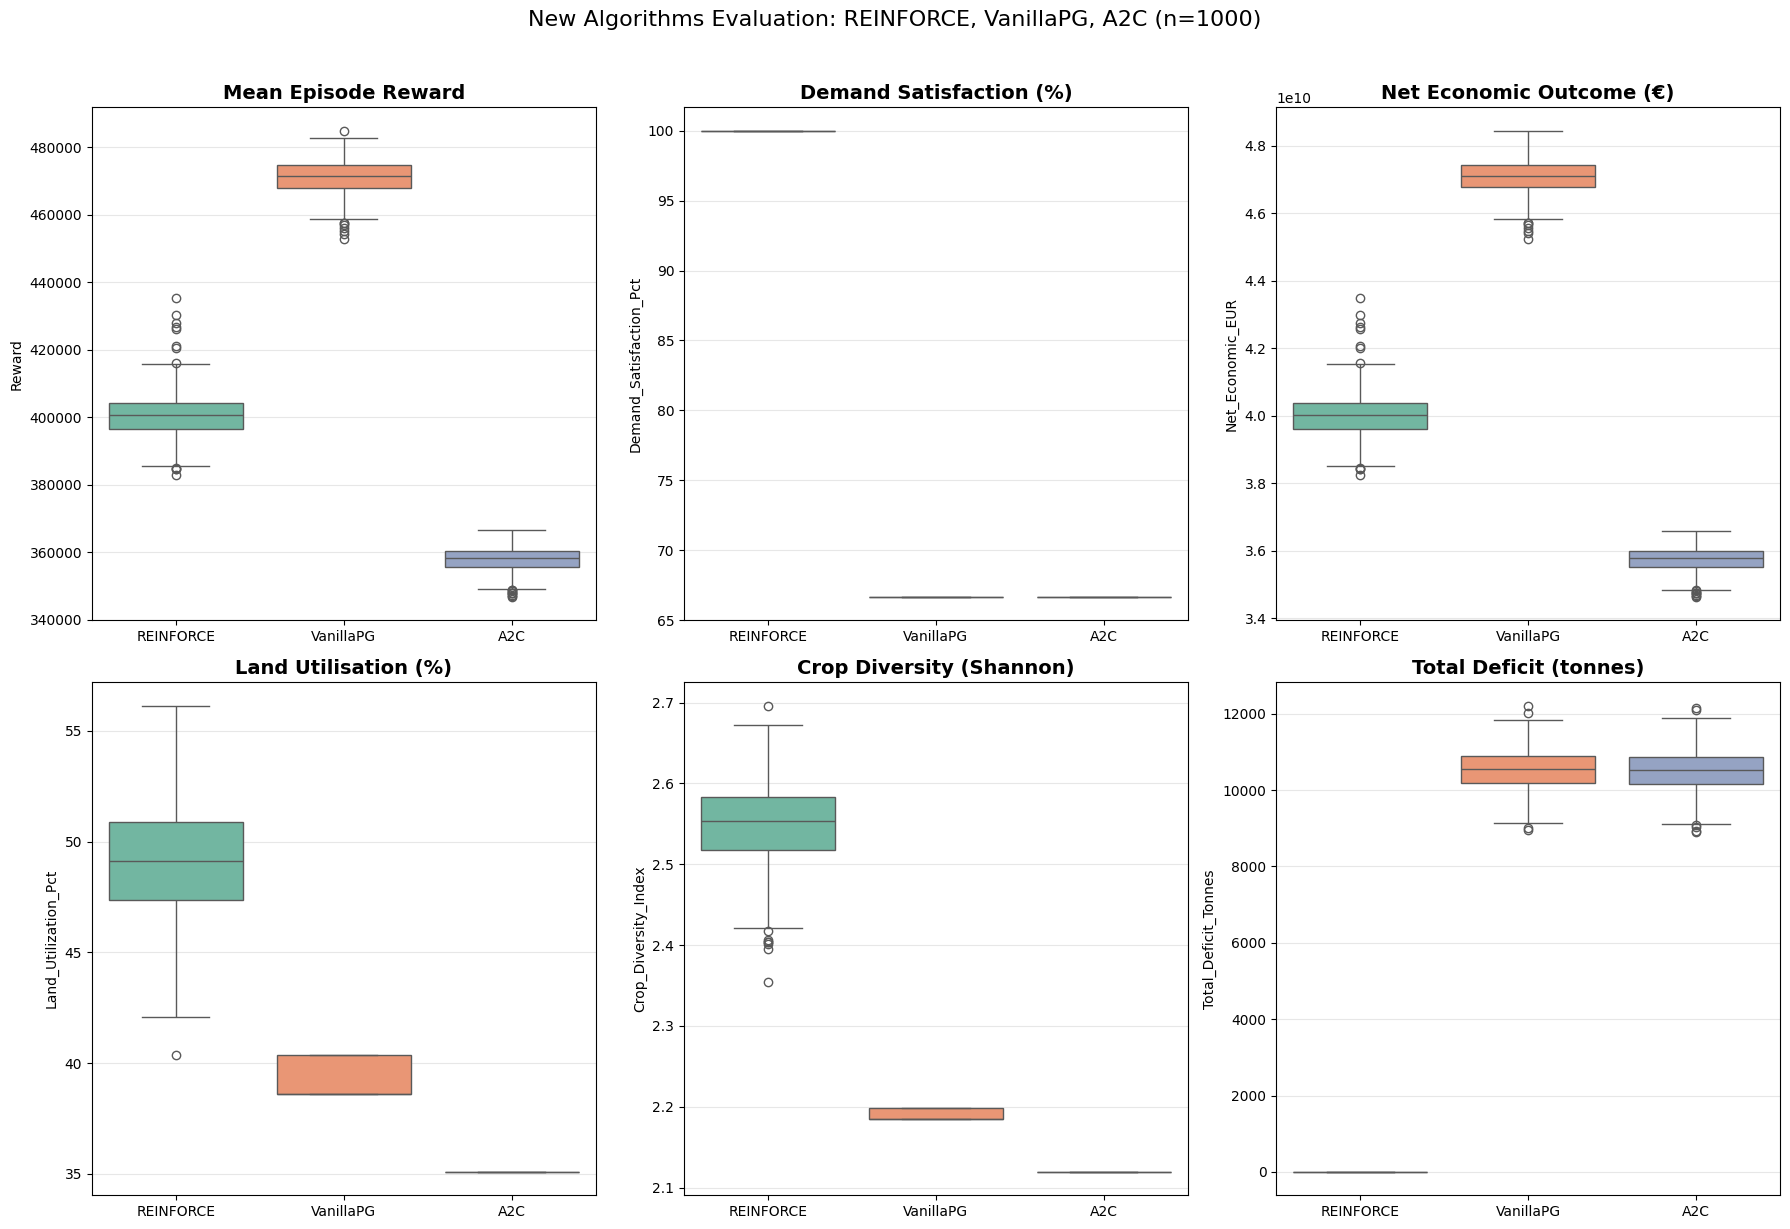

In [25]:
# Combine only the 3 new algorithm results
new_results_df = pd.concat([df_reinforce, df_vpg, df_a2c], ignore_index=True)
new_results_df.to_csv("logs/new_algorithms_evaluation_results.csv", index=False)

metric_labels_new = {
    'Reward': 'Mean Episode Reward',
    'Demand_Satisfaction_Pct': 'Demand Satisfaction (%)',
    'Net_Economic_EUR': 'Net Economic Outcome (€)',
    'Land_Utilization_Pct': 'Land Utilisation (%)',
    'Crop_Diversity_Index': 'Crop Diversity (Shannon)',
    'Total_Deficit_Tonnes': 'Total Deficit (tonnes)',
    'Export_Revenue_EUR': 'Export Revenue (€)',
    'Adverse_Weather_Ratio': 'Adverse Weather Exposure'
}

# --- Summary Statistics ---
print("\n========== NEW ALGORITHMS METRICS SUMMARY ==========")
new_summary = new_results_df.groupby('Model')[list(metric_labels_new.keys())].agg(['mean', 'std', 'median'])
print(new_summary.to_string())

# --- Pairwise Statistical Tests ---
print("\n--- Pairwise T-Tests (New Algorithms Only) ---")
new_models = ['REINFORCE', 'VanillaPG', 'A2C']
for i in range(len(new_models)):
    for j in range(i + 1, len(new_models)):
        m1, m2 = new_models[i], new_models[j]
        r1 = new_results_df[new_results_df['Model'] == m1]['Reward'].values
        r2 = new_results_df[new_results_df['Model'] == m2]['Reward'].values
        min_len = min(len(r1), len(r2))
        t_stat, p_val = stats.ttest_rel(r1[:min_len], r2[:min_len])
        sig = "*** SIGNIFICANT ***" if p_val < 0.05 else "n.s."
        print(f"{m1:>12} vs {m2:<12}: T={t_stat:>8.4f}, p={p_val:.6f}  {sig}")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
key_metrics_new = ['Reward', 'Demand_Satisfaction_Pct', 'Net_Economic_EUR',
                   'Land_Utilization_Pct', 'Crop_Diversity_Index', 'Total_Deficit_Tonnes']

palette_new = sns.color_palette("Set2", n_colors=3)
for ax, metric in zip(axes.flatten(), key_metrics_new):
    sns.boxplot(x='Model', y=metric, data=new_results_df, ax=ax, palette=palette_new,
                order=['REINFORCE', 'VanillaPG', 'A2C'])
    ax.set_title(metric_labels_new.get(metric, metric), fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('New Algorithms Evaluation: REINFORCE, VanillaPG, A2C (n=1000)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("logs/new_algorithms_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()